## 0. Tiền xử lý dữ liệu

Import các thư viện cần thiết để phân tích dữ liệu

In [1]:
import os
import gc
import dask
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import scipy.stats as stats

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
FOLDER_PATH = "../data/merged"

Gọi hàm con để xử lý dữ liệu thô được lấy từ ERA5

In [2]:
def preprocess(ds):
    if 'valid_time' in ds.coords: 
        ds = ds.rename({'valid_time': 'time'})
    if 'expver' in ds.dims: 
        ds = ds.mean(dim='expver')
    return ds.sortby('time')

Xử lý dữ liệu và nhóm lại các biến theo các danh mục khác nhau. Trong số này:
- 

In [3]:
def get_sst_wave_data_optimized(folder_path, sst_name, swh_name):
    # Load datasets
    ds_sst = preprocess(xr.open_dataset(os.path.join(folder_path, sst_name)))
    ds_swh = preprocess(xr.open_dataset(os.path.join(folder_path, swh_name)))

    # Extract variables safely
    var_sst = list(ds_sst.data_vars)[0]
    var_swh = list(ds_swh.data_vars)[0]

    # From Xarray DataSet to DataArray
    sst = ds_sst[var_sst]
    swh = ds_swh[var_swh]

    # Spatial mean reduction
    sst = sst.mean(dim=['latitude', 'longitude'])
    swh = swh.mean(dim=['latitude', 'longitude'])

    # Aggregation to daily
    # Multiply by -1 because in ERA5, evaporation means "negative", so we have to make it "positive"
    daily_sst  = (sst.resample(time="1D").mean() - 273.15)
    daily_swh  = swh.resample(time="1D").mean()

    # Only compute at this time, to maximize laziness
    daily_sst, daily_swh = dask.compute(daily_sst, daily_swh)

    # Close datasets
    ds_sst.close()
    ds_swh.close()

    # Create monthly figures
    monthly_sst  = daily_sst.resample(time="1ME").mean()
    monthly_swh  = daily_swh.resample(time="1ME").mean()

    # Create climatology figures
    clim_sst  = daily_sst.groupby("time.month").mean("time")
    clim_swh  = daily_swh.groupby("time.month").mean("time")

    # Create anomalies figures
    anom_sst  = daily_sst.groupby("time.month") - clim_sst
    anom_swh  = daily_swh.groupby("time.month") - clim_swh

    # Group 1D DataArray into a Dataset, then convert the whole to Pandas DataFrame
    df_daily = xr.Dataset({
        "sst": daily_sst,
        "swh": daily_swh,
        "anom_sst": anom_sst,
        "anom_swh": anom_swh
    }).to_dataframe()

    df_monthly = xr.Dataset({
        "sst": monthly_sst,
        "swh": monthly_swh,
    }).to_dataframe()

    df_clim = xr.Dataset({
        "sst": clim_sst,
        "swh": clim_swh,
    }).to_dataframe()

    gc.collect()

    return df_daily, df_monthly, df_clim

In [4]:
df_daily, df_monthly, df_clim = get_sst_wave_data_optimized(FOLDER_PATH, 'sea_surface_temperature_merged.nc', 'significant_height_of_combined_wind_waves_and_swell_merged.nc')

In [5]:
df_daily = df_daily.drop(columns=['number']).reset_index()
df_daily.head()

,time,sst,swh,month,anom_sst,anom_swh
0,1980-01-01,23.528351,0.806634,1,0.132940,-0.497173
1,1980-01-02,23.499817,0.755612,1,0.104406,-0.548195
2,1980-01-03,23.636139,0.754464,1,0.240728,-0.549343
3,1980-01-04,23.862823,1.287021,1,0.467413,-0.016785
4,1980-01-05,24.064178,1.730097,1,0.668768,0.426291


In [6]:
df_monthly = df_monthly.drop(columns=['number']).reset_index()
df_monthly.head()

,time,sst,swh
0,1980-01-31,23.613314,1.234544
1,1980-02-29,23.191011,1.247587
2,1980-03-31,24.455854,0.880440
3,1980-04-30,25.736141,0.899022
4,1980-05-31,28.397228,0.722486


In [7]:
df_clim = df_clim.drop(columns=['number']).reset_index()
df_clim.head()

,month,sst,swh
0,1,23.395411,1.303806
1,2,23.305773,1.111747
2,3,24.249935,0.943086
3,4,26.156878,0.782805
4,5,28.346716,0.680328


## 1. Nhiệt độ nước biển và độ cao sóng biển qua các tháng

Về nhiệt độ mặt nước biển, rõ ràng ta có thể thấy được là nhờ có gió mùa Đông Bắc vào mùa đông, nhiệt độ sẽ thấp hơn hẳn so với khi mùa hạ với gió mùa Tây Nam làm tăng nhiệt độ. Biên độ năm cũng khá lớn giữa 2 mùa, là đặc trưng của vùng biển nhiệt đới gió mùa. 

Về độ cao sóng biển lại ngược lại hoàn toàn, gió Đông Bắc khiến sóng cao hơn và gió Tây Nam làm cho độ cao biển lặng. 

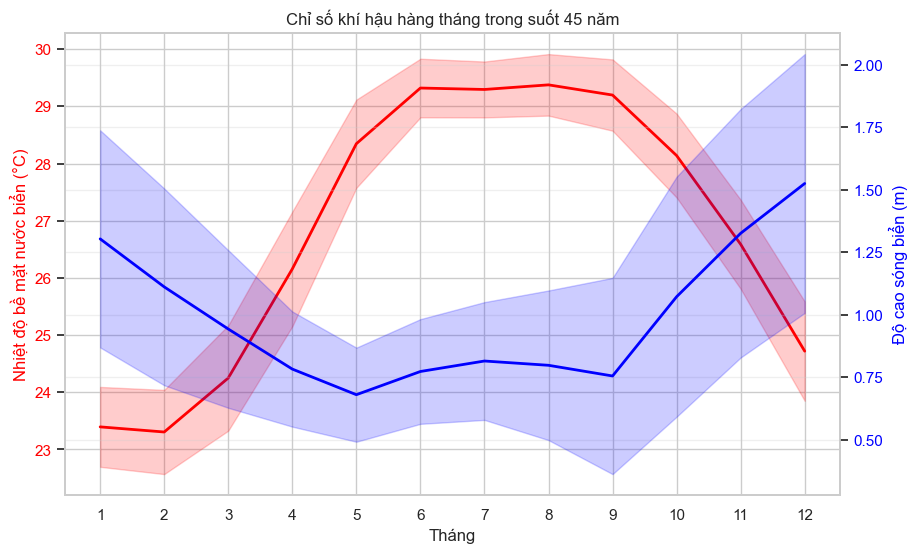

In [8]:
df_daily['time'] = pd.to_datetime(df_daily['time'])
df_daily['year'] = df_daily['time'].dt.year
df_monthly['time'] = pd.to_datetime(df_monthly['time'])
df_monthly['year'] = df_monthly['time'].dt.year

# Calculate monthly standard deviations from daily data
monthly_std = df_daily.groupby('month')[['sst', 'swh']].std().reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

# SST Plot
ax1.plot(df_clim['month'], df_clim['sst'], color='red', lw=2, label='SST Mean')
ax1.fill_between(df_clim['month'], 
                 df_clim['sst'] - monthly_std['sst'], 
                 df_clim['sst'] + monthly_std['sst'], color='red', alpha=0.2)
ax1.set_xlabel('Tháng')
ax1.set_ylabel('Nhiệt độ bề mặt nước biển (°C)', color='red')
ax1.tick_params(axis='y', labelcolor='red')

# SWH Plot
ax2 = ax1.twinx()
ax2.plot(df_clim['month'], df_clim['swh'], color='blue', lw=2, label='SWH Mean')
ax2.fill_between(df_clim['month'], 
                 df_clim['swh'] - monthly_std['swh'], 
                 df_clim['swh'] + monthly_std['swh'], color='blue', alpha=0.2)
ax2.set_ylabel('Độ cao sóng biển (m)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Chỉ số khí hậu hàng tháng trong suốt 45 năm')
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.show()

## 2. Xu hướng dài hạn của nhiệt độ mặt nước biển

Từ biểu đồ ta thấy rõ xu hướng nhiệt độ mặt nước biển đang tăng dần lên, không có gì phải bàn cãi. Do biến đổi khí hậu khiến nhiệt độ nước biển tăng lên rất nhanh, nếu như vào những năm 1980 tập trung quanh khoảng 26.6 độ, thì giờ đã tập trung trong khoảng 27.6 độ.

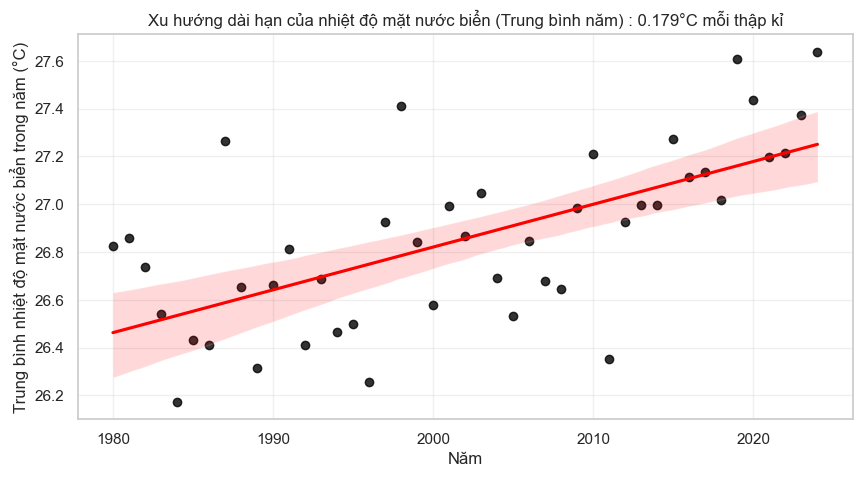

In [9]:
df_annual_sst = df_daily.groupby('year')['sst'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.regplot(data=df_annual_sst, x='year', y='sst', scatter_kws={'color':'black'}, line_kws={'color':'red'})

# Calculate Slope
slope, intercept, r_value, p_value, std_err = stats.linregress(df_annual_sst['year'], df_annual_sst['sst'])
trend_per_decade = slope * 10

plt.title(f'Xu hướng dài hạn của nhiệt độ mặt nước biển (Trung bình năm) : {trend_per_decade:.3f}°C mỗi thập kỉ')
plt.ylabel('Trung bình nhiệt độ mặt nước biển trong năm (°C)')
plt.xlabel('Năm')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Heatmap dị thường nhiệt độ mặt nước biển

Heatmap này cho ta thấy rõ ràng nhất về xu hướng tăng lên mạnh mẽ của nhiệt độ mặt nước biển. Nếu trong những năm 1980 - 1990 thì chủ đạo vẫn là màu xanh, càng về sau những năm 2010 - 2020 là những màu đỏ đậm dần. Dấu hiệu cực kì tương phản này khẳng định tình trạng biến đổi khí hậu đang càng ngày càng khiến ấm lên toàn cầu. 

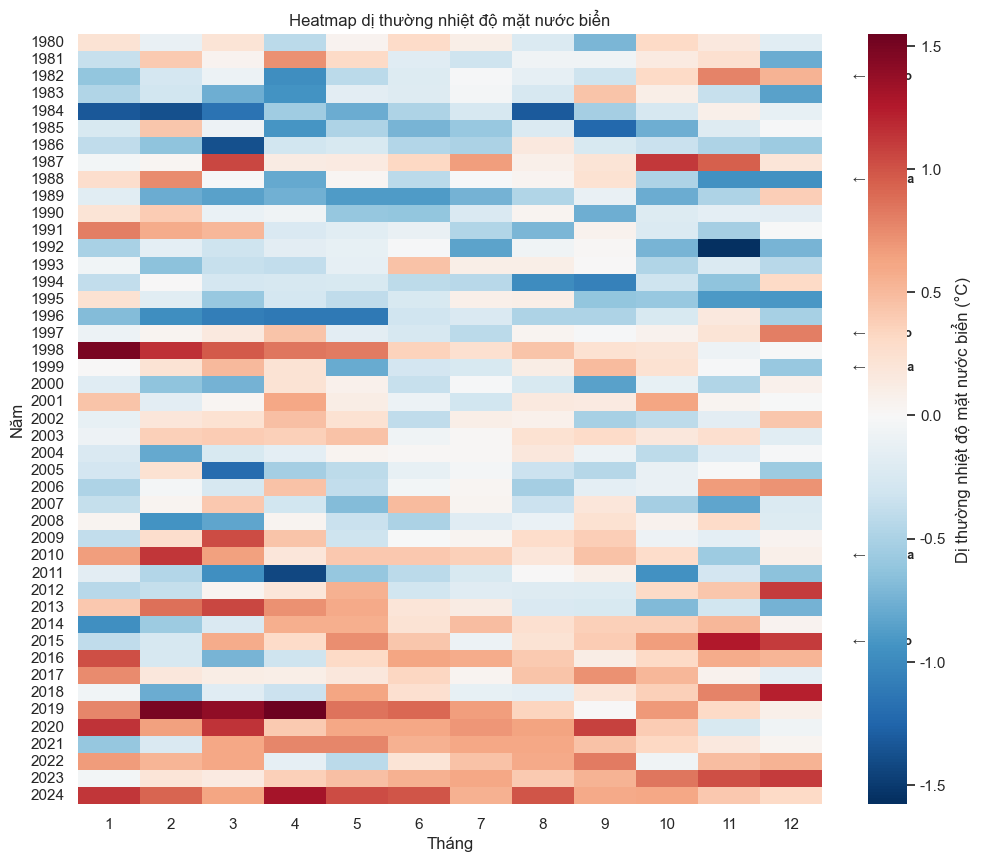

In [10]:
df_daily['month'] = df_daily['time'].dt.month
heatmap_data = df_daily.pivot_table(index='year', columns='month', values='anom_sst', aggfunc='mean')

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap='RdBu_r', center=0, cbar_kws={'label': 'Dị thường nhiệt độ mặt nước biển (°C)'})

# Highlight ENSO Years on Y-axis
enso_years = {
    'El Niño': [1982, 1997, 2015],
    'La Niña': [1988, 1999, 2010]
}
for label, years in enso_years.items():
    for yr in years:
        plt.text(12.5, yr - 1980 + 0.5, f'← {label}', va='center', fontsize=9, fontweight='bold')

plt.title('Heatmap dị thường nhiệt độ mặt nước biển')
plt.xlabel('Tháng')
plt.ylabel('Năm')
plt.show()

## 4. Xu hướng về tần suất và cường độ của các đợt nước biển nóng bất thường

Từ biểu đồ, ta thấy được rõ ràng càng ngày càng về sau các đợt nước biển nóng lên bất thường rất rất nhiều, thậm chí năm 2024 số ngày gần như nửa năm, phù hợp với xu hướng heatmap ở trên. 

Về cường độ, ở các năm trước còn có sự biến động, nhưng càng về gần đây thì các đợt nước biển nóng sẽ nóng hơn trung bình vào khoảng hơn 1 độ C.

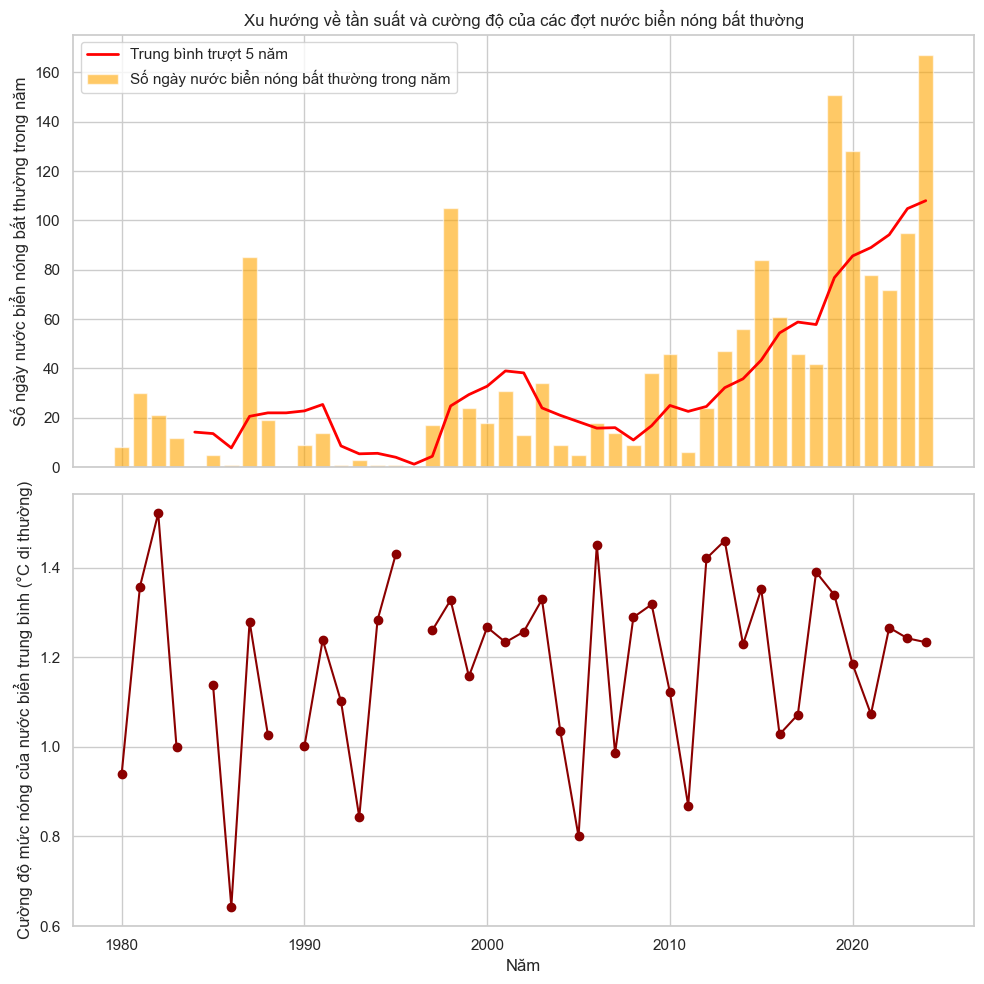

In [13]:
mhw_thresh = df_daily.groupby('month')['sst'].transform(lambda x: x.quantile(0.90))
df_daily['is_mhw'] = df_daily['sst'] > mhw_thresh

mhw_stats = df_daily.groupby('year').agg(
    mhw_days=('is_mhw', 'sum'),
    mhw_intensity=('anom_sst', lambda x: x[df_daily.loc[x.index, 'is_mhw']].mean())
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Top: Frequency
ax1.bar(mhw_stats['year'], mhw_stats['mhw_days'], color='orange', alpha=0.6, label='Số ngày nước biển nóng bất thường trong năm')
ax1.plot(mhw_stats['year'], mhw_stats['mhw_days'].rolling(5).mean(), color='red', lw=2, label='Trung bình trượt 5 năm')
ax1.set_ylabel('Số ngày nước biển nóng bất thường trong năm')
ax1.legend()
ax1.set_title('Xu hướng về tần suất và cường độ của các đợt nước biển nóng bất thường')

# Bottom: Intensity
ax2.plot(mhw_stats['year'], mhw_stats['mhw_intensity'], marker='o', color='darkred')
ax2.set_ylabel('Cường độ mức nóng của nước biển trung bình (°C dị thường)')
ax2.set_xlabel('Năm')

plt.tight_layout()
plt.show()

## 5. Tần suất sóng cực đoan và mùa bão

Vào biểu đồ, ta thấy được một xu hướng tăng khá chậm và không rõ ràng trong độ cao sóng biển, không thực sự quá biến động.

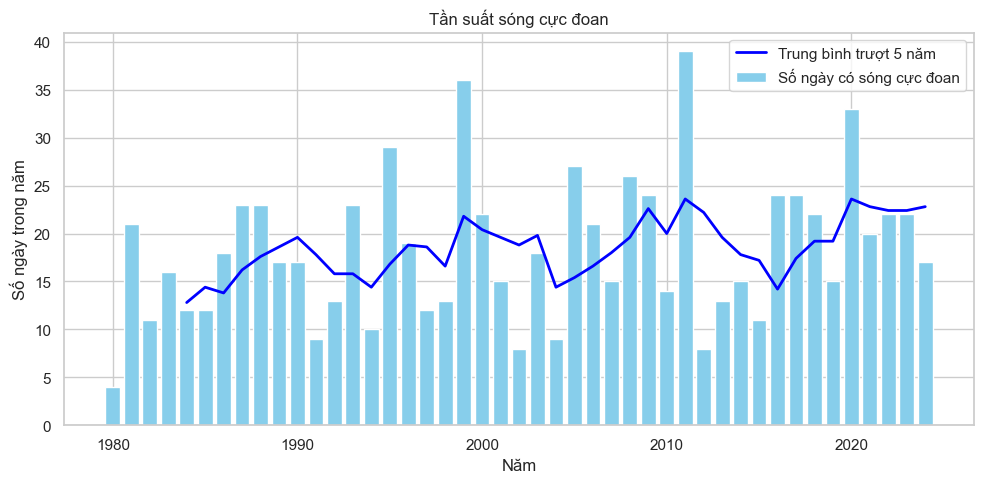

In [15]:
swh_p95 = df_daily['swh'].quantile(0.95)
df_daily['is_extreme_wave'] = df_daily['swh'] > swh_p95

# Frequency stats
wave_stats = df_daily.groupby('year').agg(
    extreme_days=('is_extreme_wave', 'sum')
).reset_index()

# Plot ONLY extreme frequency
plt.figure(figsize=(10, 5))

plt.bar(wave_stats['year'], wave_stats['extreme_days'],
        color='skyblue', label='Số ngày có sóng cực đoan')

plt.plot(wave_stats['year'],
         wave_stats['extreme_days'].rolling(5).mean(),
         color='blue', lw=2, label='Trung bình trượt 5 năm')

plt.ylabel('Số ngày trong năm')
plt.xlabel('Năm')
plt.title('Tần suất sóng cực đoan')
plt.legend()

plt.tight_layout()
plt.show()